In [21]:
# ============================================
# CUSTOMER BEHAVIOR ANALYSIS PROJECT
# ============================================

# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [22]:
# ============================================
# 2. LOAD DATASET
# ============================================

# Replace with your actual file name
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

# Display first rows
print(df.head())

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:32      Electronics             12         3   
1        46251  2022-03-05 12:56:35             Home            468         4   
2        46251  2022-05-23 18:18:01             Home            288         2   
3        46251  2020-11-12 13:13:29         Clothing            196         1   
4        13593  2020-11-27 17:55:11             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Age  Gender  Churn  
0  Christine Hernandez   37    Male      0  
1  Christine Hernandez   3

In [23]:
# ============================================
# 3. CLEAN COLUMN NAMES
# ============================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nColumns:")
print(df.columns)


Columns:
Index(['customer_id', 'purchase_date', 'product_category', 'product_price',
       'quantity', 'total_purchase_amount', 'payment_method', 'customer_age',
       'returns', 'customer_name', 'age', 'gender', 'churn'],
      dtype='object')


In [24]:
# ============================================
# 4. CHECK MISSING VALUES
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customer_id                  0
purchase_date                0
product_category             0
product_price                0
quantity                     0
total_purchase_amount        0
payment_method               0
customer_age                 0
returns                  47596
customer_name                0
age                          0
gender                       0
churn                        0
dtype: int64


In [25]:

# ============================================
# 5. DATA CLEANING
# ============================================

# Convert numeric columns safely

numeric_columns = [
    'product_price',
    'quantity',
    'total_purchase_amount',
    'customer_age',
    'age'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# Convert categorical columns to numeric

# Returns column
# If already numeric, this won't affect much

df['returns'] = df['returns'].replace({
    'Yes': 1,
    'No': 0
})

# Churn column

df['churn'] = df['churn'].replace({
    'Yes': 1,
    'No': 0
})
# Convert again to numeric after replacement

df['returns'] = pd.to_numeric(df['returns'], errors='coerce')
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')


# Remove missing values

df.dropna(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)


Dataset Shape After Cleaning:
(202404, 13)


In [26]:
# ============================================
# 6. FEATURE ENGINEERING
# ============================================

# Average spend per item

df['avg_spend_per_item'] = (
    df['total_purchase_amount'] / df['quantity']
)

# Replace infinite values if quantity = 0

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

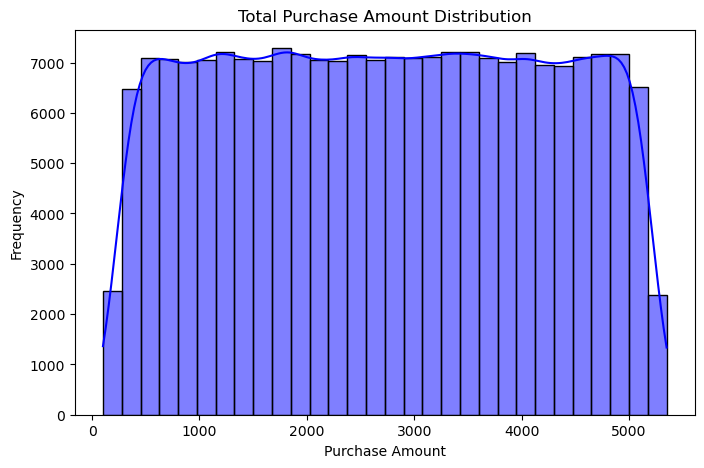

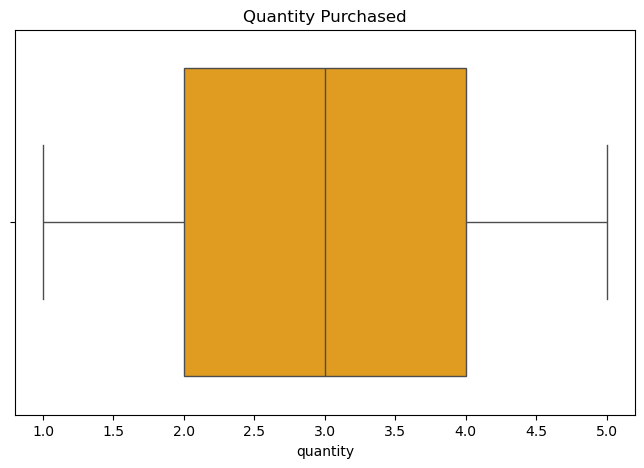

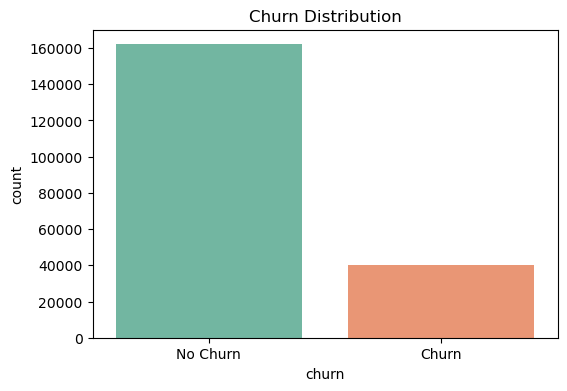

In [27]:
# ============================================
# 7. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# --------------------------------------------
# Purchase Amount Distribution
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df['total_purchase_amount'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title("Total Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()


# --------------------------------------------
# Quantity Distribution
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(x=df['quantity'], color='orange')

plt.title("Quantity Purchased")

plt.show()

# --------------------------------------------
# Churn Distribution
# --------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='churn',
    data=df,
    hue='churn',
    palette='Set2',
    legend=False
)

plt.title("Churn Distribution")

plt.xticks([0,1], ['No Churn', 'Churn'])

plt.show()


In [28]:

# ============================================
# 8. CUSTOMER SEGMENTATION
# ============================================

# Features for clustering

features = df[[
    'product_price',
    'quantity',
    'total_purchase_amount',
    'returns'
]]

In [29]:
# ============================================
# 9. FEATURE SCALING
# ============================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)


# Check NaN values before clustering

print("\nNaN values in scaled data:")
print(np.isnan(scaled_features).sum())



NaN values in scaled data:
0


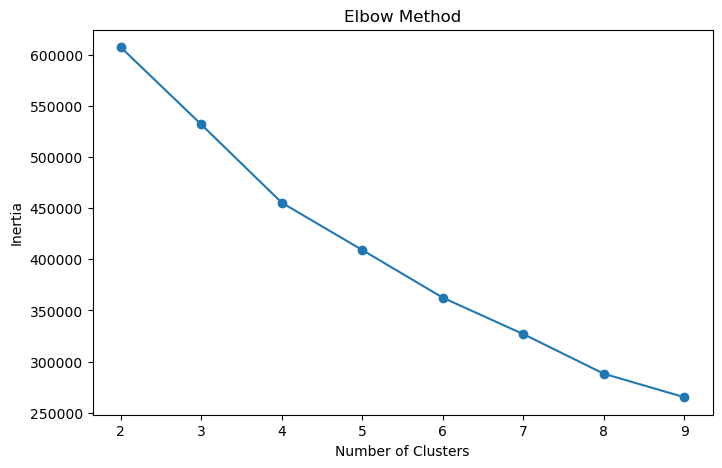

In [30]:

# ============================================
# 10. ELBOW METHOD
# ============================================

inertia = []

for k in range(2,10):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(2,10),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


In [31]:

# ============================================
# 11. APPLY KMEANS
# ============================================

# Choose clusters based on elbow graph
# Here we use 4

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(scaled_features)

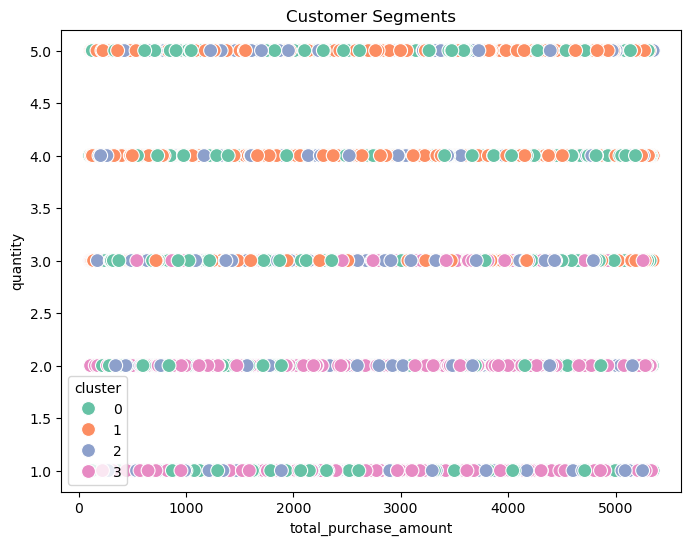

In [32]:
# ============================================
# 12. VISUALIZE CUSTOMER SEGMENTS
# ============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='total_purchase_amount',
    y='quantity',
    hue='cluster',
    data=df,
    palette='Set2',
    s=100
)

plt.title("Customer Segments")

plt.show()


In [33]:
# ============================================
# 13. SEGMENT PROFILING
# ============================================

segment_profile = df.groupby('cluster')[[
    'product_price',
    'quantity',
    'total_purchase_amount',
    'returns',
    'churn'
]].mean()

print("\nSegment Profile:")
print(segment_profile)


Segment Profile:
         product_price  quantity  total_purchase_amount  returns     churn
cluster                                                                   
0           131.582092  3.005919            2714.623745      0.0  0.200627
1           278.767270  4.201903            2734.140647      1.0  0.200810
2           377.053342  2.988185            2734.449602      0.0  0.196746
3           229.480654  1.802987            2717.278643      1.0  0.199532


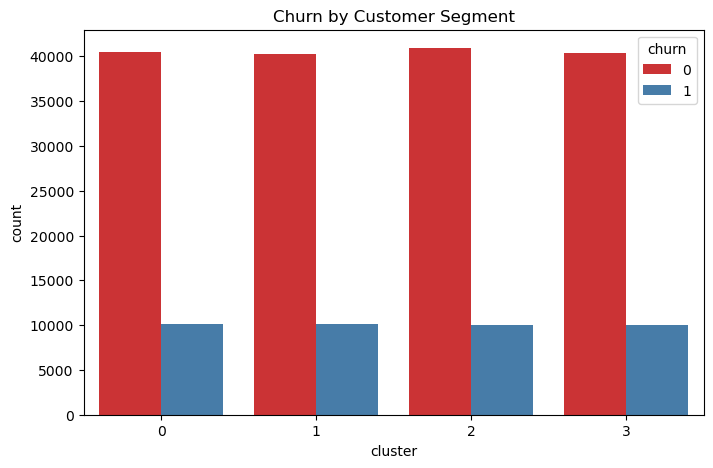

In [34]:

# ============================================
# 14. CHURN ANALYSIS
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='cluster',
    hue='churn',
    data=df,
    palette='Set1'
)

plt.title("Churn by Customer Segment")

plt.show()


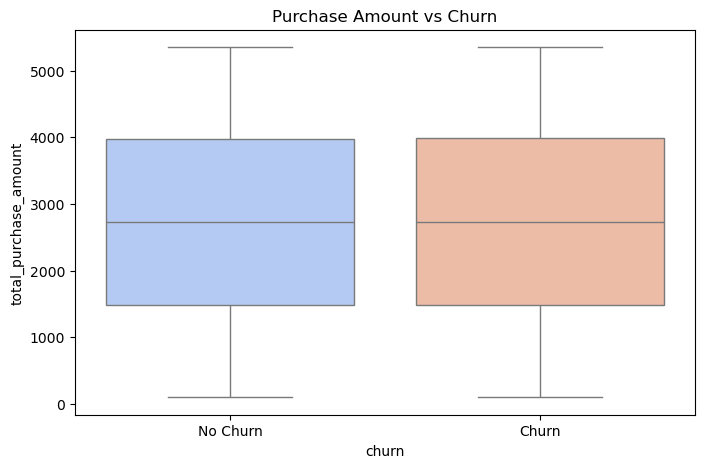

In [35]:

# ============================================
# 15. PURCHASE AMOUNT VS CHURN
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='total_purchase_amount',
    data=df,
    hue='churn',
    palette='coolwarm',
    legend=False
)

plt.title("Purchase Amount vs Churn")

plt.xticks([0,1], ['No Churn', 'Churn'])

plt.show()

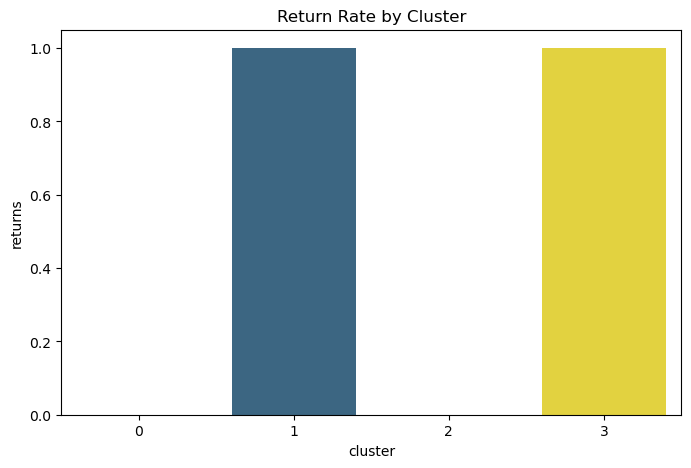

In [36]:
# ============================================
# 16. RETURN ANALYSIS
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='cluster',
    y='returns',
    data=df,
    hue='cluster',
    palette='viridis',
    legend=False
)

plt.title("Return Rate by Cluster")

plt.show()

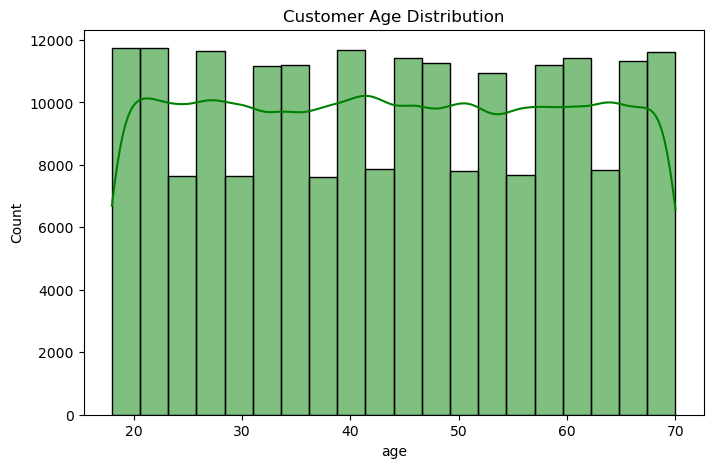

In [37]:
# ============================================
# 17. AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Customer Age Distribution")

plt.show()

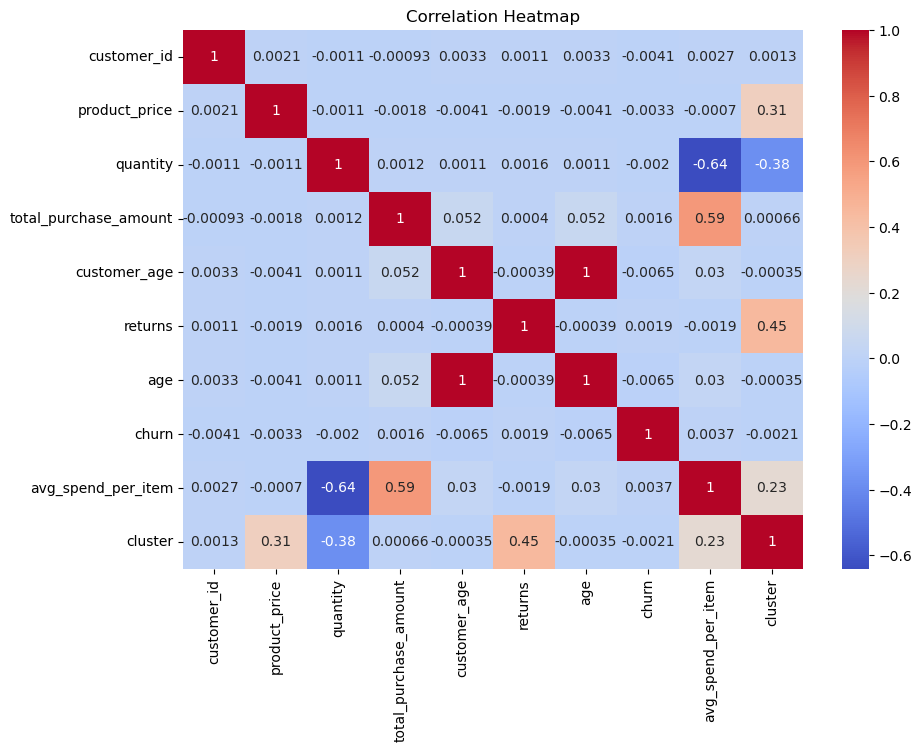

In [38]:
# ============================================
# 18. CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

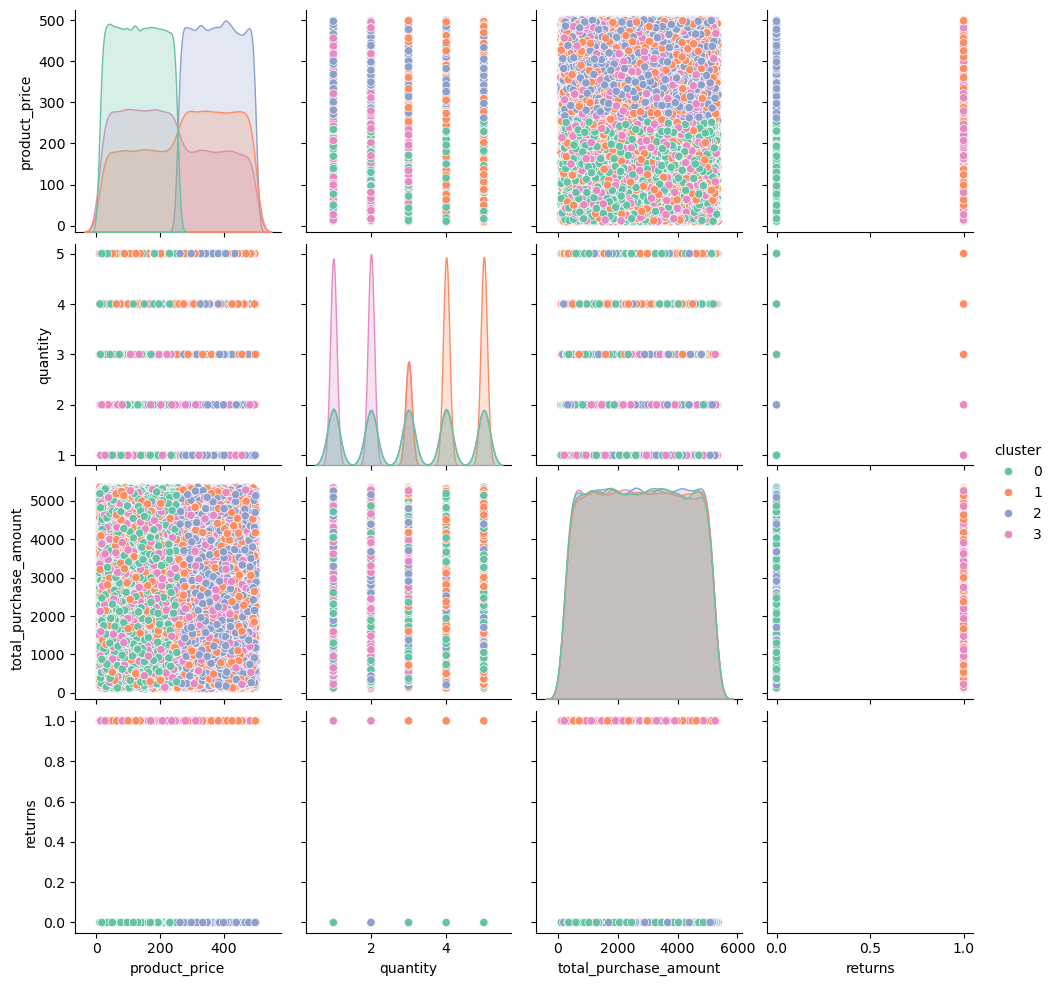

In [39]:
# ============================================
# 19. PAIRPLOT
# ============================================
sns.pairplot(
    df[[
        'product_price',
        'quantity',
        'total_purchase_amount',
        'returns',
        'cluster'
    ]],
    hue='cluster',
    palette='Set2'
)

plt.show()

In [40]:
# ============================================
# 20. BUSINESS INSIGHTS
# ============================================

print("\n================ BUSINESS INSIGHTS ================\n")

print("1. High spending customers form the most valuable segment.")
print("2. Customers with high returns may indicate dissatisfaction.")
print("3. Churned customers generally show lower purchase behavior.")
print("4. Certain clusters have stronger retention potential.")
print("5. Personalized marketing can improve engagement.")


# ============================================
# 21. RECOMMENDATIONS
# ============================================

print("\n================ RECOMMENDATIONS ================\n")

recommendations = [
    "1. Launch loyalty rewards for high-value customers.",
    "2. Re-engage churn-risk customers using personalized offers.",
    "3. Improve product quality to reduce return rates.",
    "4. Use targeted marketing based on customer segments.",
    "5. Recommend related products for cross-selling."
]

for rec in recommendations:
    print(rec)


================ BUSINESS INSIGHTS ================

1. High spending customers form the most valuable segment.
2. Customers with high returns may indicate dissatisfaction.
3. Churned customers generally show lower purchase behavior.
4. Certain clusters have stronger retention potential.
5. Personalized marketing can improve engagement.

================ RECOMMENDATIONS ================

1. Launch loyalty rewards for high-value customers.
2. Re-engage churn-risk customers using personalized offers.
3. Improve product quality to reduce return rates.
4. Use targeted marketing based on customer segments.
5. Recommend related products for cross-selling.
